In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sbn

In [2]:
Ideal_condition = pd.read_csv("Ideal_off.csv")
Ideal_fallen = pd.read_csv("Ideal_off_fallen.csv")
fallen_run = pd.read_csv("Ideal_run_fallen.csv")
fallen_run1 = pd.read_csv("Ideal_run_fallen1.csv")
Good_run1 = pd.read_csv("Ideal_run1.csv")
Good_run2 = pd.read_csv("Ideal_run2.csv")
Good_run3 = pd.read_csv("Ideal_run3.csv")
Good_run4 = pd.read_csv("Ideal_run4.csv")
Good_run5 = pd.read_csv("Ideal_run5.csv")
Good_run6 = pd.read_csv("Ideal_run6.csv")
Major_load1 = pd.read_csv("Major_load1.csv")
Major_load2 = pd.read_csv("Major_load2.csv")
Major_load3 = pd.read_csv("Major_load3.csv")
Major_load4 = pd.read_csv("Major_load4.csv")
Minor_load = pd.read_csv("Minor_load.csv")
Minor_load1 = pd.read_csv("Minor_load1.csv")
Minor_load2 = pd.read_csv("Minor_load2.csv")
Minor_load3 = pd.read_csv("Minor_load3.csv")
Minor_load4 = pd.read_csv("Minor_load4.csv")
Major_obstacle = pd.read_csv("Major_obstacle.csv")


In [3]:
Ideal_condition['Output'] = 0
Ideal_fallen['Output'] = 1
fallen_run['Output'] = 2
fallen_run1['Output'] = 2
Good_run1['Output'] = 3
Good_run2['Output'] = 3
Good_run3['Output'] = 3
Good_run4['Output'] = 3
Good_run5['Output'] = 3
Good_run6['Output'] = 3
Major_load1['Output'] = 4
Major_load2['Output'] = 4
Major_load3['Output'] = 4
Major_load4['Output'] = 4
Minor_load['Output'] = 5
Minor_load1['Output'] = 5
Minor_load2['Output'] = 5
Minor_load3['Output'] = 5
Minor_load4['Output'] = 5
Major_obstacle['Output'] = 6

In [4]:
Ultimate_Data = pd.concat([Ideal_condition, Ideal_fallen, fallen_run, fallen_run1, Good_run3, Good_run4, Good_run5, Good_run6, Good_run2, Good_run1, Major_load1, Major_load2, Major_load3, Major_load4, Minor_load, Minor_load2, Minor_load3, Minor_load4, Minor_load1, Major_obstacle], ignore_index= True)

In [5]:
Ultimate_Data = Ultimate_Data.drop(columns = ["time","Unnamed: 5"])

In [6]:
Ultimate_Data = shuffle(Ultimate_Data).reset_index(drop=True)

In [7]:
df_train, df_test = train_test_split(Ultimate_Data, test_size=0.2, random_state=42)

In [8]:
df_test

,accel_g_x,accel_g_y,accel_g_z,current_mA,Output
455875,0.072510,-0.529297,0.743408,16.612501,4
356561,0.137939,-0.482178,0.812012,25.375000,4
733910,0.005615,-0.297607,1.045654,20.412500,5
299714,-0.101807,-0.017822,1.002930,15.062500,3
134353,-0.948730,-0.017578,-0.037109,16.450001,2
...,...,...,...,...,...
219119,0.071289,0.362061,0.877686,15.737500,3
560363,0.133057,0.056641,1.201904,18.575001,4
638483,-0.894775,0.095947,0.004883,18.737501,2
762519,0.062988,-0.465820,0.912598,14.912500,5


In [9]:
MPU_Data = df_train.drop(columns = ["current_mA"])

In [10]:
INA_Data = df_train.drop(columns = ["accel_g_x", "accel_g_y", "accel_g_z"])

In [11]:
MPU_Data

,accel_g_x,accel_g_y,accel_g_z,Output
180224,-0.004639,-0.474365,0.848633,5
730142,0.041748,-0.783447,0.736816,4
367853,-0.013672,0.156738,1.082764,3
223809,-0.991943,-0.050781,-0.081299,2
364180,-0.027344,-0.072021,1.109863,5
...,...,...,...,...
259178,-0.982666,0.024414,-0.001709,1
365838,0.037598,-0.846680,0.664062,4
131932,0.112305,-0.917236,0.425781,4
671155,-0.067627,-0.350098,0.970703,4


In [12]:
x = df_train[['accel_g_x', 'accel_g_y', 'accel_g_z', 'current_mA']].values
y = df_train['Output'].values

x_MPU = df_train[['accel_g_x', 'accel_g_y', 'accel_g_z']].values
y_MPU = df_train['Output'].values

x_INA = df_train[['current_mA']].values
y_INA = df_train[['Output']].values

In [13]:
hetro_model = tf.keras.Sequential([
    keras.layers.Input(shape=(4,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(7, activation='softmax')
])
hetro_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
hetro_model.fit (x, y, epochs=15)

Epoch 1/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy: 0.7253 - loss: 0.6204
Epoch 2/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.8494 - loss: 0.3885
Epoch 3/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.8832 - loss: 0.3157
Epoch 4/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.8945 - loss: 0.2924
Epoch 5/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9000 - loss: 0.2783
Epoch 6/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9058 - loss: 0.2625
Epoch 7/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9103 - loss: 0.2497
Epoch 8/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.9144 - loss: 0.2385
Epoch 9/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9185 - loss: 0.2268
Epoch 10/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.9242 - loss: 0.2127
Epoch 11/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.9279 - loss: 0.20

In [14]:
MPU_model = tf.keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(7, activation='softmax')
])


MPU_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)


MPU_model.fit (x_MPU, y_MPU, epochs=15)

Epoch 1/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.8125 - loss: 0.4756
Epoch 2/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.8980 - loss: 0.2825
Epoch 3/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.9100 - loss: 0.2505
Epoch 4/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.9176 - loss: 0.2317
Epoch 5/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.9222 - loss: 0.2175
Epoch 6/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.9268 - loss: 0.2045
Epoch 7/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.9308 - loss: 0.1917
Epoch 8/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.9331 - loss: 0.1832
Epoch 9/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9353 - loss: 0.1763
Epoch 10/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.9376 - loss: 0.1703
Epoch 11/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.9390 - loss: 0.16

In [15]:
INA_model = tf.keras.Sequential([
    keras.layers.Input(shape=(1,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(7, activation='softmax')
])


INA_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)


INA_model.fit (x_INA, y_MPU, epochs=15)

Epoch 1/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - accuracy: 0.3629 - loss: 1.2652
Epoch 2/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.3689 - loss: 1.2316
Epoch 3/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.3693 - loss: 1.2269
Epoch 4/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.3696 - loss: 1.2253
Epoch 5/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.3697 - loss: 1.2299
Epoch 6/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.3699 - loss: 1.2247
Epoch 7/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.3701 - loss: 1.2225
Epoch 8/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.3700 - loss: 1.2219
Epoch 9/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.3698 - loss: 1.2202
Epoch 10/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.3703 - loss: 1.2203
Epoch 11/15
19598/19598 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.3702 - loss: 1.21

In [16]:
x_test = df_test[['accel_g_x', 'accel_g_y', 'accel_g_z', 'current_mA']].values
y_test = df_test['Output'].values

x_MPU_test = df_test[['accel_g_x', 'accel_g_y', 'accel_g_z']].values
y_MPU_test = df_test['Output'].values

x_INA_test = df_test[['current_mA']].values
y_INA_test = df_test[['Output']].values

4900/4900 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


<Axes: >

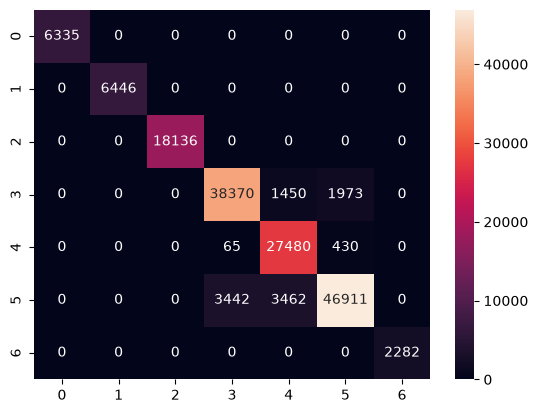

In [17]:
Hetro_predicted = hetro_model.predict(x_test)
Hetro_predicted_class = Hetro_predicted.argmax(axis=1)
cm=tf.math.confusion_matrix(Hetro_predicted_class, y_test)
sbn.heatmap(cm, annot=True, fmt='d')

4900/4900 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


<Axes: >

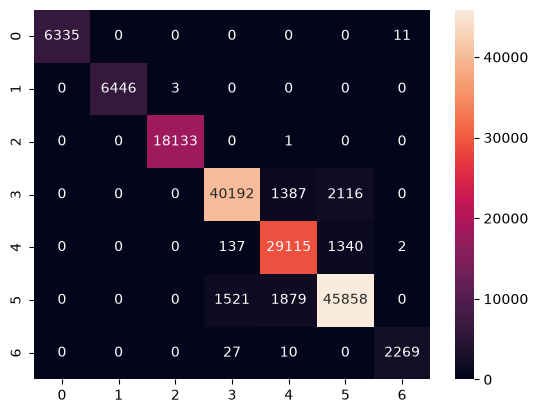

In [18]:
MPU_predicted = MPU_model.predict(x_MPU_test)
MPU_predicted_class = MPU_predicted.argmax(axis=1)
cm=tf.math.confusion_matrix(MPU_predicted_class, y_MPU_test)
sbn.heatmap(cm, annot=True, fmt='d')

4900/4900 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


<Axes: >

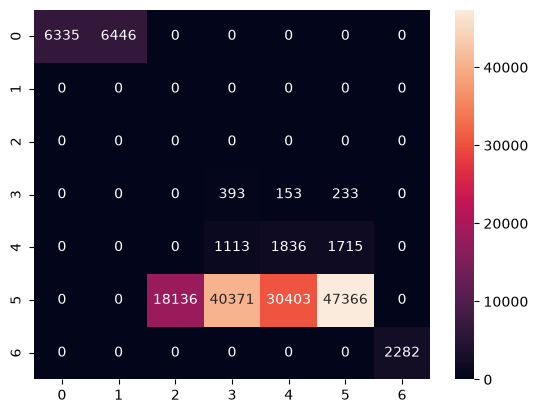

In [19]:
INA_predicted = INA_model.predict(x_INA_test)
INA_predicted_class = INA_predicted.argmax(axis=1)
cm=tf.math.confusion_matrix(INA_predicted_class, y_INA_test)
sbn.heatmap(cm, annot=True, fmt='d')

In [20]:
hetro_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 7)                   │             119 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,815 (14.91 KB)

 Trainable params: 1,271 (4.96 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,544 (9.94 KB)

In [21]:
MPU_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 7)                   │             119 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,767 (14.72 KB)

 Trainable params: 1,255 (4.90 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,512 (9.82 KB)

In [22]:
INA_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 16)                  │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 7)                   │             119 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,671 (14.34 KB)

 Trainable params: 1,223 (4.78 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,448 (9.57 KB)

In [25]:
hetro_converter = tf.lite.TFLiteConverter.from_keras_model(hetro_model)
hetro_lite_model = hetro_converter.convert()

INFO:tensorflow:Assets written to: C:\Users\rajmo\AppData\Local\Temp\tmpp0bzccfc\assets


INFO:tensorflow:Assets written to: C:\Users\rajmo\AppData\Local\Temp\tmpp0bzccfc\assets


Saved artifact at 'C:\Users\rajmo\AppData\Local\Temp\tmpp0bzccfc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2852767150736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2852767140944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778574992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778577488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2852767149968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778576912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778580944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778575952: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [26]:
with open('hetro_lite_model.tflite', 'wb') as f:
    f.write(hetro_lite_model)

In [27]:
MPU_converter = tf.lite.TFLiteConverter.from_keras_model(MPU_model)
MPU_lite_model = MPU_converter.convert()

INFO:tensorflow:Assets written to: C:\Users\rajmo\AppData\Local\Temp\tmpsu1y3cnr\assets


INFO:tensorflow:Assets written to: C:\Users\rajmo\AppData\Local\Temp\tmpsu1y3cnr\assets


Saved artifact at 'C:\Users\rajmo\AppData\Local\Temp\tmpsu1y3cnr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2853778582480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778582672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778585936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778585360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778580560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778579216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778574608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778581904: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [28]:
with open('MPU_lite_model.tflite', 'wb') as f:
    f.write(MPU_lite_model)

In [29]:
INA_converter = tf.lite.TFLiteConverter.from_keras_model(INA_model)
INA_lite_model = INA_converter.convert()

INFO:tensorflow:Assets written to: C:\Users\rajmo\AppData\Local\Temp\tmptm2ywjwi\assets


INFO:tensorflow:Assets written to: C:\Users\rajmo\AppData\Local\Temp\tmptm2ywjwi\assets


Saved artifact at 'C:\Users\rajmo\AppData\Local\Temp\tmptm2ywjwi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2853778577104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778579600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778584784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778578448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778580368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778579408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853778577296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2853780403600: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [30]:
with open('INA_lite_model.tflite', 'wb') as f:
    f.write(INA_lite_model)